# Module 1: Programming Assignment

**See Canvas for this assignment due date and submission**. Complete all of the following problems. Problems should be completed in this notebook (using the R kernel). Questions may require code, plots, analysis, interpretation, etc. Working in small groups is allowed, but it is important that you make an effort to master the material and hand in your own work. 

**This assignment contains some problems that are meant to assess whether you have the background knowledge to be successful in the course. Specifically, probability and linear algebra concepts - including joint probability distributions, random vectors, conditional distributions, expectation, variance, and matrix/vector operations - are considered prerequisite concepts. We may briefly review some of these topics in class, but if you have never seen them before, and struggle with this assignment, please reach out to me so that we can assess whether you have the background knowledge to be successful in the course. Future assignments will follow the concepts covered in lecture more closely.**

**Note from MG:** The cell above needs to be edited for Coursera.

In [1]:
# This cell loads the necesary libraries and test functions for this assignment
library(testthat)
library(ggplot2)
library(MASS)

expect_constant = function(actual, tolerance = .Machine$double.eps^0.5) {
  if (length(actual) == 0) {
    fail("The vector is empty.")
  }
  
  # Check if all elements are the same within the given tolerance
  if (all(abs(actual - actual[1]) < tolerance)) {
    succeed()
  } else {
    fail("Your answer is not proportional to the posterior.")
  }
}

## Problem 1: Bivariate normal: inference on the correlation coefficient
Assume that $(X,Y)$ follow a bivariate normal distribution with $E(X) = E(Y) = 0$ and $Var(X) = Var(Y) = 1$. The pdf of $(X,Y)$ is given as

\begin{align*}
f(x,y \, | \, \rho) = \frac{1}{2\pi\sqrt{1-\rho^2}}\exp{\left\{-\frac{x^2 - 2\rho xy + y^2}{2(1-\rho^2)} \right\} },
\end{align*}

where $\rho$ is the correlation coefficient for $X$ and $Y$. Suppose that we observe $n$ iid realizations of $(X,Y)$. That is, we observe:

| X | Y |
|---|---|
| $x_1$ | $y_1$ |
| $x_2$ | $y_2$ |
| $\vdots$ | $\vdots$ |
| $x_n$ | $y_n$ |


Suppose that the $(X,Y)$ data are given as:

In [4]:
#note the updated/corrected simulation
set.seed(7309)

mu = c(0,0)
rho = 0
Sig = matrix(c(1,rho,rho,1), ncol = 2)
    
n = 15
X = mvrnorm(n, mu, Sig)
x = X[,1]; y = X[,2]


**1 (a) [4 points] Plot the data. Calculate the correlation coefficient using cor() and store it in the variable `c`.**

In [6]:
# your code here
#.NotYetImplemented()
c = cor(x, y)
c

[1] 0.03314104

**1 (b) [3 points] Answer `TRUE` or `FALSE` for each of the following questions i., ii., and iii. Submit your answer to each by replacing the `NA`values in the code cell below with your answer to the corresponding question.**

i. The data above were generated under the assumption that the *population* correlation between $X$ and $Y$ is zero.

ii. The variable `c` in the previous part (problem 1 (a) above) is exactly zero.

iii. The variance of $X$ is $1$.

In [7]:
i = TRUE
ii = FALSE
iii = TRUE

# your code here
#.NotYetImplemented()

**The next several steps will allow us to plot the posterior distribution (up to a normalization constant, meaning, you can drop the denominator of Bayes' theorem)**

**1 (c) [2 points] Create a grid of 100 evenly spaced $\rho$ values between $-0.99$ and $0.99$. Store these in `r`.** 

HINT: the `seq()` function might be useful.

In [9]:
# your code here
#.NotYetImplemented()
r = seq(-0.99, 0.99, length.out=100)
#r

**1 (d) [4 points] Assume that $\rho \sim U(-1,1)$. Compute the prior density at each value of $\rho$ (stored in `r`directly above in 1(c)). Store this computation in `prior`.**

In [11]:
# your code here
#.NotYetImplemented()
prior = dunif(r, -1, 1)
#prior

**1 (e) [6 points] Compute the likelihood function for the $(X,Y)$ given above part (a) of this problem. Remember, the likelihood function should be a function of $\rho$ (in this case, it will be evaluated at each value of $\rho$ created in step 1). Store these in `l`.**

In [55]:
# your code here
#.NotYetImplemented()
likelihood <- function(rho) {
    ll <- -log(2) - log(pi) - 0.5*log(1-rho^2) - (x^2 - 2*rho*x*y + y^2)/(2*(1-rho^2))
    exp(sum(ll))
}
l <- sapply(r, likelihood)
#l

**1 (f) [6 points] Compute the posterior distribution, up to a normalizing constant, at each value of $\rho$ (`r`) and store in `post`.**

In [51]:
# your code here
post <- prior * l
#.NotYetImplemented()
#post

**1 (g) [4 points] Plot the `post`, the posterior up to a constant, as a function of $\rho$ in ggplot.  Save the plot as `p`.**

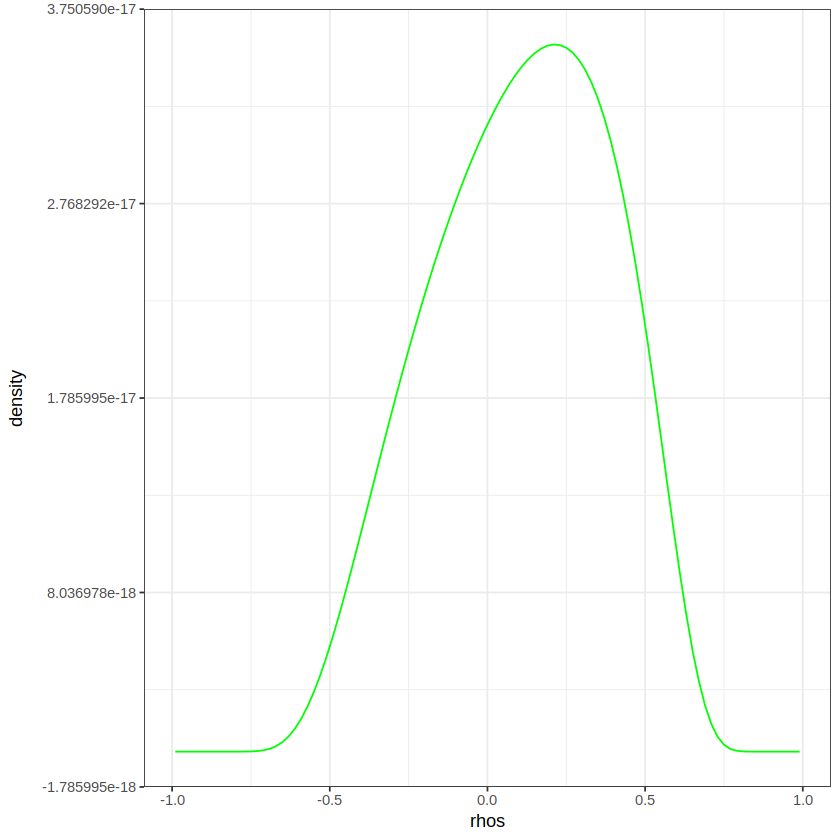

In [54]:
# your code here
library(ggplot2)
df <- data.frame(rhos = r, prior=prior, ll=l, post=post)
#.NotYetImplemented()
p <- ggplot(df) +
    #geom_line(aes(rhos, prior), col='red') + 
    #geom_line(aes(rhos, ll), col='blue') +
    geom_line(aes(rhos, post), col='green') +
    xlab('rhos') +
    ylab('density') +
    theme_bw()
p

**1 (h) [2 points] Answer `TRUE` or `FALSE` for each of the following questions i. and ii.. Submit your answer to each by replacing the `NA`values in the code cell below with your answer to the corresponding question.**

i. The posterior distribution (up to a constant) plotted in the previous part looks normally distributed.

ii. The posterior distribution (up to a constant) plotted in the previous part has a positive mode.

In [ ]:
i = FALSE
ii = TRUE

# your code here
#.NotYetImplemented()

## Problem 2: Basic posterior inference 

**Suppose you have a Beta(4, 4) prior distribution on the probability $\theta$ that a coin will yield a ‘head’ when flipped in a specified manner. The coin is independently flipped ten times, and ‘heads’ appear fewer than $3$ times. You are not told how many heads were seen, only that the number is less than $3$. Calculate your exact posterior density (up to a proportionality constant) for $\theta$ and sketch it.**

**2 (a) [3 points] Create a grid of $100$ evenly spaced $\theta$ values between $0.01$ and $0.99$. Store these in `theta`.**


HINT: the `seq()` function might be helpful.

In [32]:
# your code here
#.NotYetImplemented()
theta = seq(0.01, 0.99, length.out=100)

**2 (b) [6 points] Calculate the posterior density (up to a proportionality constant) at each value of $\theta$ and store as `post`.**

In [44]:
# your code here
#.NotYetImplemented()
n <- 10

compute.post <- function(p) {
    dbeta(p, 4, 4) * pbinom(2, n, p)
}

#p <- 0.2
#pbinom(2, n, p)
#sum(dbinom(0:2, n, p))

post = sapply(theta, compute.post)

**2 (c) [3 points] Plot the posterior as a function of $\theta$ in ggplot and store it as `p`.  Print `p`.**

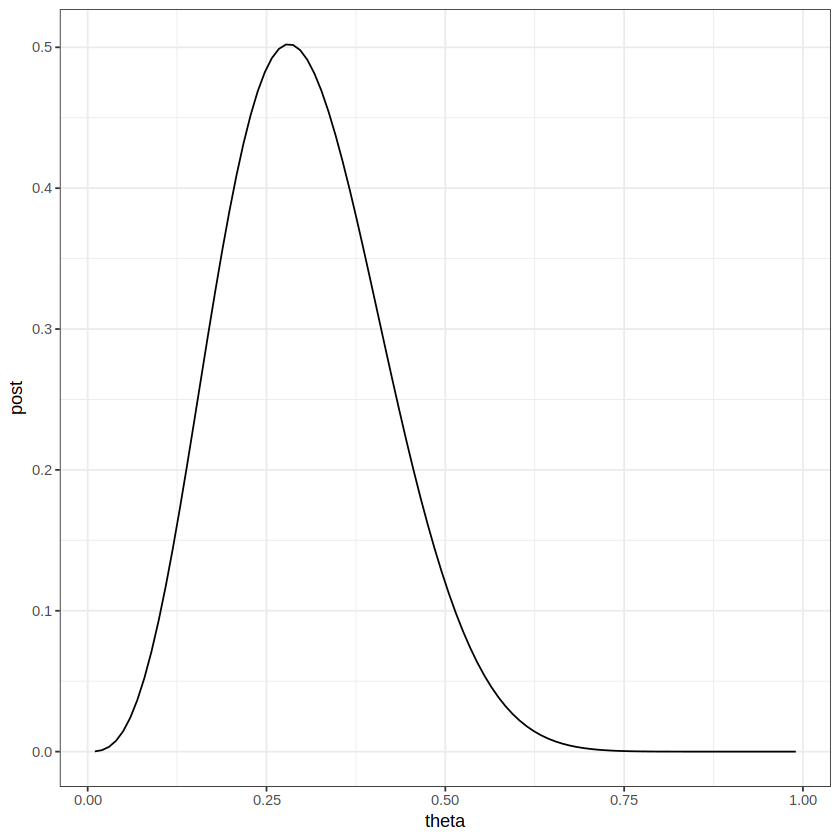

In [45]:
# your code here
#.NotYetImplemented()
df <- data.frame(theta=theta, post=post)
p <- ggplot(df, aes(theta, post)) + geom_line() + theme_bw()
print(p)